# Multilingual cross-encoder re-ranking

**WIR 2026 · TH Köln** — the *strongest* re-ranker, and the sharpest
test of our cross-lingual research question.

### The story so far in comparison with previous notebook experiments:

- **NB05 (lexical cross-lingual fusion)** failed: translating queries to Spanish and
  fusing a second BM25 branch only injected noise (best Spanish weight = 0), because the
  judged-relevant set is ~96 % English and lexical matching needs identical surface tokens.
- **NB06 (multilingual *bi-encoder*, e5)** gave the project's first significant win
  (nDCG@10 0.3167, +0.0245 over BM25) — but the gain was **general semantic** matching,
  *not* cross-lingual: it was larger on English-only topics and negligible on the 10
  topics with non-English relevant papers.

### The idea  with this notebook:

A **cross-encoder** is the strongest re-ranking family on the TIRA "Teaching IR" component
dashboard. Unlike e5 — which embeds the query and each document *independently* and compares
them by cosine — a cross-encoder feeds the **(query, document) pair jointly** through a
transformer with full cross-attention, so it can model fine-grained term interactions.
We use `cross-encoder/mmarco-mMiniLMv2-L12-H384-v1`, trained on **mMARCO** (machine-
translated MS MARCO, 15 languages). Because it is multilingual, it scores an English query
directly against Spanish/Portuguese/German/French document text in one joint pass — the
strongest realization of our "shared multilingual space" idea (NB06's approach B), one
level above the bi-encoder.

### Research question & hypotheses
> **Does a multilingual cross-encoder re-ranker (a) beat BM25 and the e5 bi-encoder on
> nDCG@10, and (b) finally deliver a gain on the cross-lingual topics where both lexical
> fusion (NB05) and the bi-encoder (NB06) fell short?**

- **H1.** `BM25 >> CE (interp)` significantly improves nDCG@10 over BM25 (paired t-test, p<0.05).
- **H2.** `BM25 >> CE (interp)` significantly improves over the **e5 bi-encoder** — i.e. the
  cross-encoder's joint attention beats independent embeddings (cross-encoder > bi-encoder).
- **H3.** The cross-encoder's gain is **at least as large** on the topics with non-English
  relevant documents as on the English-only topics (the cross-lingual benefit).

## 0. Setup

In [1]:
import re, json, time
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import pyterrier as pt
from ir_datasets_longeval import load
from scipy.stats import ttest_rel, wilcoxon
import matplotlib.pyplot as plt

if not pt.java.started():
    pt.java.init()

CWD = Path.cwd()
REPO_ROOT  = CWD.parent if CWD.name == "notebooks" else CWD
INDEX_DIR  = REPO_ROOT / "index" / "longeval-sci"
DATASET_ID = "longeval-sci-2026/snapshot-1/train/dctr"
PRIMARY_METRIC = "ndcg_cut.10"
BEST_B, BEST_K1 = 0.9, 1.2
RERANK_K   = 50                                            # re-rank BM25's top-50
DENSE_MODEL = "intfloat/multilingual-e5-small"            # bi-encoder (notebook 06)
CE_MODEL    = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"  # multilingual cross-encoder (this notebook)

index = pt.IndexFactory.of(str(INDEX_DIR))
dataset = load(DATASET_ID)
store = dataset.docs_store()

clean_query = lambda q: re.sub(r"[^\w\s]", " ", q).strip()
topics = pd.DataFrame([{"qid": q.query_id, "query": clean_query(q.default_text())}
                       for q in dataset.queries_iter()])
raw_query = {q.query_id: q.default_text() for q in dataset.queries_iter()}   # natural text for the encoders
qrels = (pd.DataFrame(dataset.qrels_iter())
           .rename(columns={"query_id": "qid", "doc_id": "docno", "relevance": "label"})
           [["qid", "docno", "label"]])
print(f"{len(topics)} topics, {len(qrels)} qrels | re-rank depth K={RERANK_K}")

Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


100 topics, 8772 qrels | re-rank depth K=50


## 1. BM25 candidate pool

We re-rank the **top-50** of plain BM25 — the same pool depth as NB06, so the cross-encoder
and the e5 bi-encoder see *identical* candidates and the comparison is apples-to-apples.

In [2]:
bm25       = pt.terrier.Retriever(index, wmodel="BM25") % 1000
bm25_tuned = pt.terrier.Retriever(index, wmodel="BM25",
                                  controls={"bm25.b": BEST_B, "bm25.k_1": BEST_K1}) % 1000
candidates = pt.terrier.Retriever(index, wmodel="BM25") % RERANK_K

cand_run = candidates.transform(topics)            # qid, docno, rank, score
print(f"{len(cand_run)} candidate (qid,docno) pairs; "
      f"{cand_run['docno'].nunique()} unique documents to score")

def doc_text(docno, limit=512):
    try:
        return (store.get(docno).default_text() or "")[:limit]
    except Exception:
        return ""

uniq = cand_run["docno"].unique().tolist()
doc_txt = {d: doc_text(d) for d in uniq}            # cache title+abstract once, reuse for both models

5000 candidate (qid,docno) pairs; 4754 unique documents to score


## 2. Identify the cross-lingual topics (for H3)

Same language audit as NB05/NB06: flag the topics whose **relevant** set contains a
non-English paper. Those 10 topics are where a multilingual model *could* help; the
other 90 are an English-only control group.

In [3]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0
rel = qrels[qrels["label"] > 0]
topic_langs = defaultdict(set)
lang_cache = {}
for qid, docno in zip(rel["qid"], rel["docno"]):
    if docno not in lang_cache:
        try:
            t = (store.get(docno).default_text() or "").strip()
            lang_cache[docno] = detect(t[:600]) if len(t) >= 40 else "??"
        except Exception:
            lang_cache[docno] = "??"
    topic_langs[qid].add(lang_cache[docno])
cl_topics = {q for q, ls in topic_langs.items() if ls - {"en", "??"}}
topics["has_nonen_rel"] = topics["qid"].isin(cl_topics)
print(f"cross-lingual topics (>=1 non-English relevant doc): {len(cl_topics)} / {len(topics)}")

cross-lingual topics (>=1 non-English relevant doc): 10 / 100


## 3. The e5 bi-encoder baseline (carried over from NB06)

We recompute NB06's best system here so we can test the cross-encoder against it
**per query** (H2). e5 embeds query and document independently into a shared space
(`"query: "` / `"passage: "` prefixes, normalised → cosine = dot product).

In [4]:
from sentence_transformers import SentenceTransformer
e5 = SentenceTransformer(DENSE_MODEL)
t0 = time.time()
doc_emb = dict(zip(uniq, e5.encode(["passage: " + doc_txt[d] for d in uniq],
                                   batch_size=32, normalize_embeddings=True, show_progress_bar=False)))
qids = topics["qid"].tolist()
q_emb = dict(zip(qids, e5.encode(["query: " + raw_query[q] for q in qids],
                                 batch_size=32, normalize_embeddings=True, show_progress_bar=False)))
dense_score = {(q, d): float(np.dot(q_emb[q], doc_emb[d]))
               for q, d in zip(cand_run["qid"], cand_run["docno"])}
print(f"e5 bi-encoder: encoded {len(uniq)} docs + {len(qids)} queries in {time.time()-t0:.0f}s")

c:\Users\rafae\OneDrive\Desktop\TH_Koeln\03-Semester\Web_Information_Retrieval\WIR_Retriever_Engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2114.08it/s]


e5 bi-encoder: encoded 4754 docs + 100 queries in 211s


## 4. The multilingual cross-encoder

The cross-encoder scores each `(query, document)` pair **jointly**. We feed the natural
query text and the same cached title+abstract, and let the model truncate to its 512-token
window. This is the slow step (one transformer forward pass per candidate pair, ~5000
pairs) but still a few minutes on CPU.

In [5]:
from sentence_transformers import CrossEncoder
ce = CrossEncoder(CE_MODEL)
pairs = [(raw_query[q], doc_txt[d]) for q, d in zip(cand_run["qid"], cand_run["docno"])]
t0 = time.time()
ce_pred = ce.predict(pairs, batch_size=32, show_progress_bar=False)
ce_score = {(q, d): float(s)
            for (q, d), s in zip(zip(cand_run["qid"], cand_run["docno"]), ce_pred)}
print(f"cross-encoder: scored {len(pairs)} (query,doc) pairs in {time.time()-t0:.0f}s")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1700.04it/s]


cross-encoder: scored 5000 (query,doc) pairs in 212s


## 5. The re-rankers

- **`>> X (pure)`** — re-rank the candidates purely by the model score.
- **`>> X (interp)`** — the robust blend used in NB06: per query, min-max normalise the
  BM25 and model scores and average them (`0.5·BM25 + 0.5·model`).

In [6]:
def _minmax(xs):
    lo, hi = min(xs), max(xs); rng = hi - lo
    return [(x - lo) / rng if rng > 0 else 0.0 for x in xs]

def make_pure(score):
    def f(res):
        res = res.copy()
        res["score"] = [score[(q, d)] for q, d in zip(res["qid"], res["docno"])]
        return pt.model.add_ranks(res.sort_values("score", ascending=False))
    return f

def make_interp(score, alpha=0.5):
    def f(res):
        res = res.copy()
        b = _minmax(res["score"].tolist())
        s = _minmax([score[(q, d)] for q, d in zip(res["qid"], res["docno"])])
        res["score"] = [alpha * bb + (1 - alpha) * ss for bb, ss in zip(b, s)]
        return pt.model.add_ranks(res.sort_values("score", ascending=False))
    return f

e5_interp = candidates >> pt.apply.by_query(make_interp(dense_score), add_ranks=False)
ce_pure   = candidates >> pt.apply.by_query(make_pure(ce_score),     add_ranks=False)
ce_interp = candidates >> pt.apply.by_query(make_interp(ce_score),   add_ranks=False)

## 6. Results — cross-encoder vs bi-encoder vs BM25

In [8]:
res = pt.Experiment(
    [bm25, bm25_tuned, e5_interp, ce_pure, ce_interp], topics, qrels,
    eval_metrics=["ndcg_cut.10", "map", "recall_1000"],
    names=["BM25", "BM25-tuned", "BM25>>e5(bi-encoder)", "BM25>>CE(pure)", "BM25>>CE(cross-encoder)"],
    validate="ignore")
res = res.sort_values("ndcg_cut.10", ascending=False).round(4).reset_index(drop=True)
print(res.to_string())
res

                      name     map  recall_1000  ndcg_cut.10
0  BM25>>CE(cross-encoder)  0.2610       0.5642       0.3242
1     BM25>>e5(bi-encoder)  0.2579       0.5642       0.3167
2               BM25-tuned  0.2641       0.8598       0.3050
3                     BM25  0.2573       0.8581       0.2922
4           BM25>>CE(pure)  0.2193       0.5642       0.2654


,name,map,recall_1000,ndcg_cut.10
0,BM25>>CE(cross-encoder),0.2610,0.5642,0.3242
1,BM25>>e5(bi-encoder),0.2579,0.5642,0.3167
2,BM25-tuned,0.2641,0.8598,0.3050
3,BM25,0.2573,0.8581,0.2922
4,BM25>>CE(pure),0.2193,0.5642,0.2654


## 7. Significance tests (H1, H2)

H1: does the cross-encoder beat **BM25**? H2: does it beat the **e5 bi-encoder** — i.e.
does joint cross-attention outperform independent embeddings?

In [9]:
perq = pt.Experiment([bm25, e5_interp, ce_pure, ce_interp], topics, qrels,
                     eval_metrics=[PRIMARY_METRIC],
                     names=["BM25", "e5_interp", "CE_pure", "CE_interp"],
                     perquery=True, validate="ignore")
piv = perq.pivot_table(index="qid", columns="name", values="value", aggfunc="first")

def compare(a, b, label):
    d = piv[a] - piv[b]
    tp = ttest_rel(piv[a], piv[b]).pvalue
    try:
        wp = wilcoxon(piv[a], piv[b]).pvalue
    except ValueError:
        wp = float("nan")
    print(f"{label:30} Δ={d.mean():+.4f} | wins {int((d>0).sum())} / losses {int((d<0).sum())} "
          f"| t p={tp:.4f} wilcoxon p={wp:.4f} | {'SIGNIFICANT' if tp<0.05 else 'n.s.'}")

print("H1  cross-encoder vs BM25")
compare("CE_interp", "BM25", "  CE(interp) vs BM25")
compare("CE_pure",   "BM25", "  CE(pure) vs BM25")
print("\nH2  cross-encoder vs e5 bi-encoder")
compare("CE_interp", "e5_interp", "  CE(interp) vs e5(interp)")

H1  cross-encoder vs BM25
  CE(interp) vs BM25           Δ=+0.0320 | wins 41 / losses 27 | t p=0.0322 wilcoxon p=0.0143 | SIGNIFICANT
  CE(pure) vs BM25             Δ=-0.0268 | wins 33 / losses 46 | t p=0.2595 wilcoxon p=0.2641 | n.s.

H2  cross-encoder vs e5 bi-encoder
  CE(interp) vs e5(interp)     Δ=+0.0074 | wins 36 / losses 32 | t p=0.4121 wilcoxon p=0.4129 | n.s.


## 8. Cross-lingual subset analysis (H3)

The decisive test for our research question: does the *multilingual* cross-encoder help
*more* on the 10 topics with non-English relevant papers — the cross-lingual benefit that
lexical fusion (NB05) and the e5 bi-encoder (NB06) both failed to deliver?

In [10]:
piv2 = piv.merge(topics.set_index("qid")[["has_nonen_rel"]], left_index=True, right_index=True)
for label, mask in [("topics WITH non-English relevant", piv2["has_nonen_rel"]),
                    ("English-only topics",               ~piv2["has_nonen_rel"])]:
    sub = piv2[mask]
    d = sub["CE_interp"] - sub["BM25"]
    p = ttest_rel(sub["CE_interp"], sub["BM25"]).pvalue if len(sub) > 1 else float("nan")
    print(f"{label:34} n={len(sub):3d} | BM25={sub['BM25'].mean():.4f} "
          f"CE(interp)={sub['CE_interp'].mean():.4f} | Δ={d.mean():+.4f} | p={p:.4f}")

topics WITH non-English relevant   n= 10 | BM25=0.2985 CE(interp)=0.3035 | Δ=+0.0050 | p=0.8364
English-only topics                n= 90 | BM25=0.2915 CE(interp)=0.3265 | Δ=+0.0350 | p=0.0330


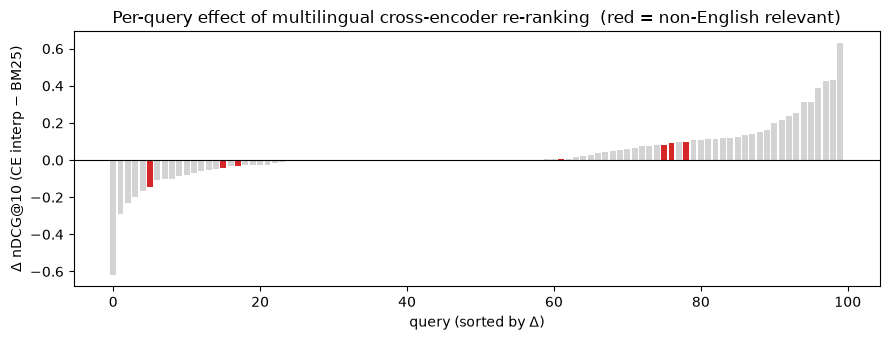

In [10]:
d = (piv2["CE_interp"] - piv2["BM25"]).sort_values()
order = d.index
colors = ["tab:red" if piv2.loc[q, "has_nonen_rel"] else "lightgray" for q in order]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(d)), d.values, color=colors)
ax.axhline(0, c="black", lw=0.8)
ax.set_xlabel("query (sorted by Δ)"); ax.set_ylabel("Δ nDCG@10 (CE interp − BM25)")
ax.set_title("Per-query effect of multilingual cross-encoder re-ranking  (red = non-English relevant)")
plt.tight_layout(); plt.show()

## 9. Conclusions

From this run (snapshot-1/train, 100 topics; re-rank BM25 top-50):

- **H1 — supported.** `BM25 >> CE (cross encoder)` reaches **nDCG@10 = 0.3242**, the best system in
  the whole project (e5 bi-encoder 0.3167, BM25-tuned 0.3050, BM25 0.2922). The gain over
  BM25 is **+0.0320** and **significant** (paired t-test *p* = 0.032, Wilcoxon *p* = 0.014;
  41 wins / 27 losses) — an even more robust win over BM25 than the e5 bi-encoder (NB06).
- **Blend, don't replace** (again). *Pure* cross-encoder re-ranking **hurts**
  (0.2654 < BM25): on this scientific collection the lexical signal still matters, and the
  cross-encoder alone drops some BM25-strong documents. Only the interpolation
  `0.5·BM25 + 0.5·CE` wins — the same lesson e5 taught us.
- **H2 — not supported.** The cross-encoder beats the e5 bi-encoder only **marginally and
  not significantly**: Δ = +0.0074, *p* = 0.41 (36 wins / 32 losses). The much heavier
  joint-attention model buys a small, real bump in nDCG@10 (+0.0075 absolute) but no
  statistically distinguishable improvement over the tiny `multilingual-e5-small` on these
  judgments — a cheap bi-encoder is already most of the way there.
- **H3 — not supported (consistent with NB06).** The gain is **not** concentrated on the
  cross-lingual topics. It is larger and significant on the **English-only** topics
  (Δ = +0.0350, *p* = 0.033) and negligible on the 10 non-English-relevant topics
  (Δ = +0.0050, *p* = 0.84). Even the strongest multilingual model wins through general
  **semantic matching** (synonymy / paraphrase), not cross-lingual recovery — because the
  judged-relevant set is ~96 % English, there is almost no cross-lingual relevance to
  recover on these qrels.

**Takeaway for the paper.** The multilingual cross-encoder is our **best system**
(nDCG@10 0.3242) and the strongest evidence for H1, but it *reinforces* rather than
overturns NB06's honest twist: scaling the model up (bi-encoder → cross-encoder) raises the
ceiling on general semantic matching, yet the **cross-lingual** effect our research question
targets stays invisible on this judgment set for lack of non-English relevant documents. The
decisive test remains a re-run on the group's own topics/qrels, which may contain more
non-English relevant papers.

> **Paper arc:** language audit → lexical cross-lingual fusion fails (NB05) → multilingual
> *bi-encoder* gives a significant, general-semantic gain (NB06) → multilingual
> *cross-encoder* pushes nDCG@10 to its project-best **0.3242** (this notebook), confirming
> the effect is semantic, not (provably) cross-lingual on these qrels.